# Mixamo 姿态关键点可视化与标准格式转换 v2

这个 notebook 默认**放在你给出的数据根目录**下运行，也就是和 `01 visual_view`、`02 visual_view` ... 同级。

它包含四部分：

1. 自动发现并读取 `bone_coordinates_pixels / image / cam` 三种坐标；同时读取 `Bounding_Box.json`；
2. 将三种坐标都画到渲染图上预览，可视化时同步绘制 bbox；
3. 将 Mixamo 骨骼转换到常见标准姿态格式（COCO-17 / OpenPose-18），并提供严格标准版本；
   - 画面外的点 visibility=0，画面内可见点 visibility=2；
   - 导出 JSON 中附带 bbox 字段（COCO 规范）；
4. 使用 **RTMLib wholebody** 在渲染图上补全 `nose / left_eye / right_eye / left_ear / right_ear`；
   - **若面部区域在画面外则自动跳过补全**；
5. 最终成品 COCO-17 可视化 widget（只显示可见点，即 visibility=2）。

In [1]:
# !pip install -U matplotlib numpy pillow opencv-python ipywidgets tqdm
# !pip install -U rtmlib onnxruntime onnxruntime-gpu

In [2]:
import json
import math
import os
from pathlib import Path
from collections import OrderedDict, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from IPython.display import display
import ipywidgets as widgets

try:
    import cv2
except Exception:
    cv2 = None

# RTMLib 默认运行配置
RTMLIB_DEVICE = 'cuda'
RTMLIB_BACKEND = 'onnxruntime'

ROOT = Path('./68 model').resolve()
VIEW_DIRS = sorted([p for p in ROOT.iterdir() if p.is_dir() and p.name.endswith('visual_view')])
print('ROOT =', ROOT)
print('发现视角目录:')
for p in VIEW_DIRS:
    print(' -', p.name)

ROOT = /home/tvem/anime/AniPose/68 model
发现视角目录:
 - 01 visual_view
 - 02 visual_view
 - 03 visual_view
 - 04 visual_view
 - 05 visual_view


In [3]:
plt.rcParams['font.sans-serif'] = ['AR PL UKai CN']
plt.rcParams['axes.unicode_minus'] = False

# 目录配置、基本读取

In [4]:
def view_prefix(view_dir: Path) -> str:
    # "01 visual_view" -> "01"
    return view_dir.name.split()[0]


def rendering_dir(view_dir: Path) -> Path:
    prefix = view_prefix(view_dir)
    return view_dir / f"{prefix}_1 Rendering"


def coord_path(view_dir: Path, mode: str) -> Path:
    prefix = view_prefix(view_dir)
    mapping = {
        'pixels': view_dir / f"{prefix}_9 bone_coordinates_pixels.json",
        'image':  view_dir / f"{prefix}_8 bone_coordinates_image.json",
        'cam':    view_dir / f"{prefix}_7 bone_coordinates_cam.json",
    }
    return mapping[mode]


def bbox_path(view_dir: Path) -> Path:
    prefix = view_prefix(view_dir)
    return view_dir / f"{prefix}_10 Bounding_Box.json"


def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def try_load_coords(view_dir: Path, mode: str):
    path = coord_path(view_dir, mode)
    if not path.exists():
        raise FileNotFoundError(f'404: {path}')
    return load_json(path)


def load_bbox_for_frame(view_dir: Path, frame_id: int):
    """
    读取 Bounding_Box.json，返回该帧的 bbox。
    原始格式示例: {"0056_1": [816, 242, 717, 1198], ...}
    key 格式: 'XXXX_1' （帧号4位+下划线+相机编号）
    返回格式: [x, y, w, h]  (假设原始即为 COCO 格式 x,y,w,h)
    若找不到返回 None。
    """
    path = bbox_path(view_dir)
    if not path.exists():
        return None
    data = load_json(path)
    # 从目录名提取相机编号，如 "02 visual_view" -> "2"
    cam_id = view_prefix(view_dir).lstrip('0') or '1'
    candidates = [
        f"{frame_id:04d}_{cam_id}",
        f"{frame_id:04d}_1",
        f"{frame_id}_{cam_id}",
        str(frame_id),
        f"{frame_id:04d}",
    ]
    for key in candidates:
        if key in data:
            return data[key]
    return None


def sorted_render_images(view_dir: Path):
    rdir = rendering_dir(view_dir)
    if not rdir.exists():
        return []
    exts = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}
    return [p for p in sorted(rdir.iterdir()) if p.suffix.lower() in exts]


def list_render_images(view_dir: Path):
    return sorted_render_images(view_dir)


def frame_image_path(view_dir: Path, frame_id: int):
    imgs = list_render_images(view_dir)
    if not imgs:
        raise FileNotFoundError(f'rendering目录下没有图片: {rendering_dir(view_dir)}')
    for p in imgs:
        digits = ''.join(ch for ch in p.stem if ch.isdigit())
        if digits and int(digits) == frame_id:
            return p
    idx = max(0, min(len(imgs)-1, frame_id-1))
    return imgs[idx]


def read_image_rgb(path: Path) -> np.ndarray:
    img = Image.open(path).convert('RGB')
    return np.array(img)


print('每个视角渲染图数量:')
for vd in VIEW_DIRS:
    has_bbox = bbox_path(vd).exists()
    print(f' - {vd.name}: {len(list_render_images(vd))} frames, bbox={has_bbox}')

每个视角渲染图数量:
 - 01 visual_view: 72 frames, bbox=True
 - 02 visual_view: 72 frames, bbox=True
 - 03 visual_view: 72 frames, bbox=True
 - 04 visual_view: 72 frames, bbox=True
 - 05 visual_view: 72 frames, bbox=True


# JSON 坐标解析

In [5]:
def _as_xy(item):
    if isinstance(item, dict):
        if 'x' in item and 'y' in item:
            return float(item['x']), float(item['y']), float(item.get('z', 0.0))
        low = {str(k).lower(): v for k, v in item.items()}
        if 'x' in low and 'y' in low:
            return float(low['x']), float(low['y']), float(low.get('z', 0.0))
    elif isinstance(item, (list, tuple)) and len(item) >= 2:
        x = float(item[0]); y = float(item[1]); z = float(item[2]) if len(item) > 2 else 0.0
        return x, y, z
    return None


def parse_frame_points(frame_obj):
    out = OrderedDict()
    if isinstance(frame_obj, dict):
        ok = False
        for k, v in frame_obj.items():
            xy = _as_xy(v)
            if xy is not None:
                out[k] = {'x': xy[0], 'y': xy[1], 'z': xy[2]}
                ok = True
        if ok:
            return out
        for key in ['bones', 'joints', 'data', 'points', 'keypoints']:
            if key in frame_obj and isinstance(frame_obj[key], dict):
                return parse_frame_points(frame_obj[key])
        for k, v in frame_obj.items():
            if isinstance(v, dict):
                nested = parse_frame_points(v)
                if nested:
                    return nested
    elif isinstance(frame_obj, list):
        for item in frame_obj:
            if isinstance(item, dict):
                name = item.get('name') or item.get('joint') or item.get('bone')
                xy = _as_xy(item)
                if name is not None and xy is not None:
                    out[str(name)] = {'x': xy[0], 'y': xy[1], 'z': xy[2]}
        if out:
            return out
    return out


def load_points_for_frame(view_dir: Path, mode: str, frame_id: int):
    data = try_load_coords(view_dir, mode)
    key = str(frame_id)
    if key not in data:
        candidates = [key, f"{frame_id:04d}", str(frame_id-1), f"{frame_id-1:04d}"]
        for c in candidates:
            if c in data:
                key = c
                break
        else:
            raise KeyError(f'{mode} 中找不到 frame={frame_id}，可用键示例: {list(data.keys())[:5]}')
    pts = parse_frame_points(data[key])
    if not pts:
        raise ValueError(f'无法解析 {mode} 的 frame={frame_id} 关键点结构')
    return pts


# 抽样检查
sample_view = VIEW_DIRS[0]
for mode in ['pixels', 'image', 'cam']:
    pts = load_points_for_frame(sample_view, mode, 1)
    print(mode, '关键点数 =', len(pts), '示例 =', list(pts.keys())[:8])

sample_bbox = load_bbox_for_frame(sample_view, 1)
print('frame=1 bbox =', sample_bbox)

pixels 关键点数 = 65 示例 = ['mixamorig:Hips', 'mixamorig:Spine', 'mixamorig:Spine1', 'mixamorig:Spine2', 'mixamorig:Neck', 'mixamorig:Head', 'mixamorig:HeadTop_End', 'mixamorig:LeftShoulder']
image 关键点数 = 65 示例 = ['mixamorig:Hips', 'mixamorig:Spine', 'mixamorig:Spine1', 'mixamorig:Spine2', 'mixamorig:Neck', 'mixamorig:Head', 'mixamorig:HeadTop_End', 'mixamorig:LeftShoulder']
cam 关键点数 = 65 示例 = ['mixamorig:Hips', 'mixamorig:Spine', 'mixamorig:Spine1', 'mixamorig:Spine2', 'mixamorig:Neck', 'mixamorig:Head', 'mixamorig:HeadTop_End', 'mixamorig:LeftShoulder']
frame=1 bbox = [810, 389, 707, 1051]


## 骨架连线（Mixamo）

In [6]:
MIXAMO_EDGES = [
    ('mixamorig:Hips', 'mixamorig:Spine'),
    ('mixamorig:Spine', 'mixamorig:Spine1'),
    ('mixamorig:Spine1', 'mixamorig:Spine2'),
    ('mixamorig:Spine2', 'mixamorig:Neck'),
    ('mixamorig:Neck', 'mixamorig:Head'),
    ('mixamorig:Head', 'mixamorig:HeadTop_End'),
    ('mixamorig:Neck', 'mixamorig:LeftShoulder'),
    ('mixamorig:LeftShoulder', 'mixamorig:LeftArm'),
    ('mixamorig:LeftArm', 'mixamorig:LeftForeArm'),
    ('mixamorig:LeftForeArm', 'mixamorig:LeftHand'),
    ('mixamorig:Neck', 'mixamorig:RightShoulder'),
    ('mixamorig:RightShoulder', 'mixamorig:RightArm'),
    ('mixamorig:RightArm', 'mixamorig:RightForeArm'),
    ('mixamorig:RightForeArm', 'mixamorig:RightHand'),
    ('mixamorig:Hips', 'mixamorig:LeftUpLeg'),
    ('mixamorig:LeftUpLeg', 'mixamorig:LeftLeg'),
    ('mixamorig:LeftLeg', 'mixamorig:LeftFoot'),
    ('mixamorig:LeftFoot', 'mixamorig:LeftToeBase'),
    ('mixamorig:LeftToeBase', 'mixamorig:LeftToe_End'),
    ('mixamorig:Hips', 'mixamorig:RightUpLeg'),
    ('mixamorig:RightUpLeg', 'mixamorig:RightLeg'),
    ('mixamorig:RightLeg', 'mixamorig:RightFoot'),
    ('mixamorig:RightFoot', 'mixamorig:RightToeBase'),
    ('mixamorig:RightToeBase', 'mixamorig:RightToe_End'),
]

LEFT_HAND_FINGERS = [
    ['mixamorig:LeftHand', 'mixamorig:LeftHandThumb1', 'mixamorig:LeftHandThumb2', 'mixamorig:LeftHandThumb3', 'mixamorig:LeftHandThumb4'],
    ['mixamorig:LeftHand', 'mixamorig:LeftHandIndex1', 'mixamorig:LeftHandIndex2', 'mixamorig:LeftHandIndex3', 'mixamorig:LeftHandIndex4'],
    ['mixamorig:LeftHand', 'mixamorig:LeftHandMiddle1', 'mixamorig:LeftHandMiddle2', 'mixamorig:LeftHandMiddle3', 'mixamorig:LeftHandMiddle4'],
    ['mixamorig:LeftHand', 'mixamorig:LeftHandRing1', 'mixamorig:LeftHandRing2', 'mixamorig:LeftHandRing3', 'mixamorig:LeftHandRing4'],
    ['mixamorig:LeftHand', 'mixamorig:LeftHandPinky1', 'mixamorig:LeftHandPinky2', 'mixamorig:LeftHandPinky3', 'mixamorig:LeftHandPinky4'],
]
RIGHT_HAND_FINGERS = [
    ['mixamorig:RightHand', 'mixamorig:RightHandThumb1', 'mixamorig:RightHandThumb2', 'mixamorig:RightHandThumb3', 'mixamorig:RightHandThumb4'],
    ['mixamorig:RightHand', 'mixamorig:RightHandIndex1', 'mixamorig:RightHandIndex2', 'mixamorig:RightHandIndex3', 'mixamorig:RightHandIndex4'],
    ['mixamorig:RightHand', 'mixamorig:RightHandMiddle1', 'mixamorig:RightHandMiddle2', 'mixamorig:RightHandMiddle3', 'mixamorig:RightHandMiddle4'],
    ['mixamorig:RightHand', 'mixamorig:RightHandRing1', 'mixamorig:RightHandRing2', 'mixamorig:RightHandRing3', 'mixamorig:RightHandRing4'],
    ['mixamorig:RightHand', 'mixamorig:RightHandPinky1', 'mixamorig:RightHandPinky2', 'mixamorig:RightHandPinky3', 'mixamorig:RightHandPinky4'],
]

for finger in LEFT_HAND_FINGERS + RIGHT_HAND_FINGERS:
    for a, b in zip(finger[:-1], finger[1:]):
        MIXAMO_EDGES.append((a, b))


def draw_bbox(ax, bbox, color='lime', linewidth=2, label=None):
    """
    在 ax 上绘制 bbox。
    bbox 格式: [x, y, w, h]  (COCO 格式)
    """
    if bbox is None:
        return
    x, y, w, h = bbox[0], bbox[1], bbox[2], bbox[3]
    rect = mpatches.Rectangle(
        (x, y), w, h,
        linewidth=linewidth, edgecolor=color, facecolor='none', label=label
    )
    ax.add_patch(rect)


def draw_points(ax, points, title='', image=None, show_labels=False, edges=None,
                invert_y=False, point_size=20, bbox=None):
    if image is not None:
        ax.imshow(image)
    xs = [v['x'] for v in points.values()]
    ys = [v['y'] for v in points.values()]
    ax.scatter(xs, ys, s=point_size)
    if edges:
        for a, b in edges:
            if a in points and b in points:
                ax.plot([points[a]['x'], points[b]['x']],
                        [points[a]['y'], points[b]['y']], linewidth=1)
    if show_labels:
        for name, p in points.items():
            ax.text(p['x'], p['y'], name.split(':')[-1], fontsize=7)
    if bbox is not None:
        draw_bbox(ax, bbox, color='lime', linewidth=2, label='bbox')
    ax.set_title(title)
    if invert_y and image is None:
        ax.invert_yaxis()
    ax.set_aspect('equal', adjustable='box')

## 坐标模式对比预览（含 bbox）

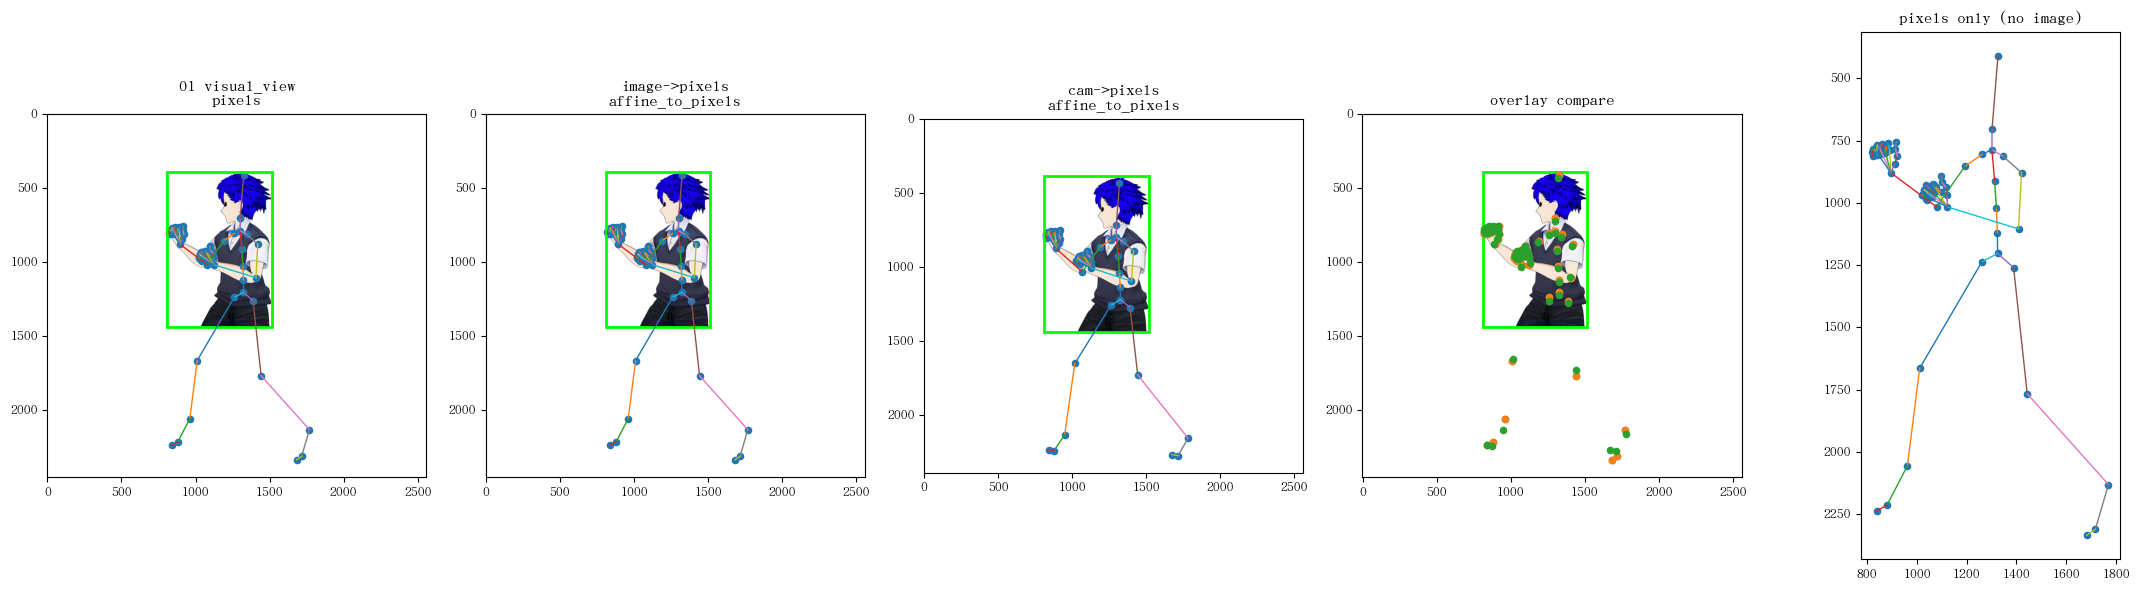

image 对齐信息: {'method': 'affine_to_pixels', 'num_common': 65}
cam   对齐信息: {'method': 'affine_to_pixels', 'num_common': 65}
bbox: [810, 389, 707, 1051]


In [7]:
def maybe_project_to_2d(points):
    out = OrderedDict()
    for k, v in points.items():
        out[k] = {'x': float(v['x']), 'y': float(v['y']), 'z': float(v.get('z', 0.0))}
    return out


def points_dict_to_xy(points, joint_names=None):
    if joint_names is None:
        joint_names = list(points.keys())
    names, xy = [], []
    for n in joint_names:
        if n in points:
            names.append(n)
            xy.append([points[n]['x'], points[n]['y']])
    if not xy:
        return [], np.zeros((0, 2), dtype=float)
    return names, np.asarray(xy, dtype=float)


def apply_affine_to_points(points, A, t):
    out = OrderedDict()
    for k, v in points.items():
        src = np.array([float(v['x']), float(v['y'])], dtype=float)
        dst = src @ A.T + t
        out[k] = {'x': float(dst[0]), 'y': float(dst[1]), 'z': float(v.get('z', 0.0))}
    return out


def fit_affine_from_correspondences(src_points, dst_points, min_joints=6):
    common = [k for k in src_points if k in dst_points]
    if len(common) < min_joints:
        raise ValueError(f'共同点太少: {len(common)} < {min_joints}')
    _, src_xy = points_dict_to_xy(src_points, common)
    _, dst_xy = points_dict_to_xy(dst_points, common)
    X = np.concatenate([src_xy, np.ones((len(src_xy), 1))], axis=1)
    M, *_ = np.linalg.lstsq(X, dst_xy, rcond=None)
    A = M[:2, :].T
    t = M[2, :]
    return A, t, common


def normalize_points_to_image(points, img_shape, keep_aspect=True, pad=0.05):
    h, w = img_shape[:2]
    xs = np.array([v['x'] for v in points.values()], dtype=float)
    ys = np.array([v['y'] for v in points.values()], dtype=float)
    min_x, max_x = xs.min(), xs.max()
    min_y, max_y = ys.min(), ys.max()
    src_w = max(max_x - min_x, 1e-6)
    src_h = max(max_y - min_y, 1e-6)
    tgt_w = w * (1 - 2*pad)
    tgt_h = h * (1 - 2*pad)
    if keep_aspect:
        s = min(tgt_w/src_w, tgt_h/src_h)
        sx = sy = s
    else:
        sx = tgt_w/src_w; sy = tgt_h/src_h
    tx = w*pad - min_x*sx + (tgt_w - src_w*sx)/2
    ty = h*pad - min_y*sy + (tgt_h - src_h*sy)/2
    A = np.array([[sx, 0.0], [0.0, sy]], dtype=float)
    t = np.array([tx, ty], dtype=float)
    return apply_affine_to_points(points, A, t), A, t


def align_points_to_pixels(src_points, pixel_points, img_shape=None, min_joints=6):
    try:
        A, t, common = fit_affine_from_correspondences(src_points, pixel_points, min_joints)
        return apply_affine_to_points(src_points, A, t), {'method': 'affine_to_pixels', 'num_common': len(common)}
    except Exception as e:
        if img_shape is None:
            raise
        aligned, A, t = normalize_points_to_image(src_points, img_shape)
        return aligned, {'method': 'normalize_fallback', 'reason': str(e)}


def compare_coordinate_modes(view_name=None, frame_id=1, show_labels=False, figsize=(22, 6)):
    view_dir = VIEW_DIRS[0] if view_name is None else next(p for p in VIEW_DIRS if p.name == view_name)
    img = read_image_rgb(frame_image_path(view_dir, frame_id))
    bbox = load_bbox_for_frame(view_dir, frame_id)

    pixels = maybe_project_to_2d(load_points_for_frame(view_dir, 'pixels', frame_id))
    imagep = maybe_project_to_2d(load_points_for_frame(view_dir, 'image', frame_id))
    camp   = maybe_project_to_2d(load_points_for_frame(view_dir, 'cam', frame_id))

    imagep_aligned, image_meta = align_points_to_pixels(imagep, pixels, img.shape)
    camp_aligned, cam_meta     = align_points_to_pixels(camp, pixels, img.shape)

    fig, axes = plt.subplots(1, 5, figsize=figsize)
    draw_points(axes[0], pixels, f'{view_dir.name}\npixels', img, show_labels, MIXAMO_EDGES, bbox=bbox)
    draw_points(axes[1], imagep_aligned, f'image->pixels\n{image_meta["method"]}', img, show_labels, MIXAMO_EDGES, bbox=bbox)
    draw_points(axes[2], camp_aligned, f'cam->pixels\n{cam_meta["method"]}', img, show_labels, MIXAMO_EDGES, bbox=bbox)
    # overlay
    axes[3].imshow(img)
    draw_bbox(axes[3], bbox, color='lime', linewidth=2)
    for pts in [pixels, imagep_aligned, camp_aligned]:
        draw_points(axes[3], pts, image=None, edges=None)
    axes[3].set_title('overlay compare')
    draw_points(axes[4], pixels, 'pixels only (no image)', None, show_labels, MIXAMO_EDGES, invert_y=True)

    plt.tight_layout()
    plt.show()
    print('image 对齐信息:', image_meta)
    print('cam   对齐信息:', cam_meta)
    print('bbox:', bbox)


compare_coordinate_modes(frame_id=1, show_labels=False)

交互式预览：三种 coordinate 模式 + bbox

In [8]:
view_dropdown = widgets.Dropdown(options=[p.name for p in VIEW_DIRS], value=VIEW_DIRS[0].name, description='View')
frame_slider  = widgets.IntSlider(value=1, min=1, max=72, step=1, description='Frame')
label_check   = widgets.Checkbox(value=False, description='显示标签')

ui  = widgets.HBox([view_dropdown, frame_slider, label_check])
out = widgets.interactive_output(
    lambda view_name, frame_id, show_labels: compare_coordinate_modes(view_name=view_name, frame_id=frame_id, show_labels=show_labels),
    {'view_name': view_dropdown, 'frame_id': frame_slider, 'show_labels': label_check}
)
display(ui, out)

Output()

# 标准格式映射（COCO-17 / OpenPose-18）

In [9]:
# COCO-17
COCO17_ORDER = [
    'nose',
    'left_eye', 'right_eye',
    'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder',
    'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist',
    'left_hip', 'right_hip',
    'left_knee', 'right_knee',
    'left_ankle', 'right_ankle',
]


COCO17_EDGES = [
    # 原有连线
    ('left_eye', 'right_eye'),
    ('nose', 'left_eye'), ('nose', 'right_eye'),
    ('left_eye', 'left_ear'), ('right_eye', 'right_ear'),
    ('left_shoulder', 'right_shoulder'),
    ('left_shoulder', 'left_elbow'), ('left_elbow', 'left_wrist'),
    ('right_shoulder', 'right_elbow'), ('right_elbow', 'right_wrist'),
    ('left_shoulder', 'left_hip'), ('right_shoulder', 'right_hip'),
    ('left_hip', 'right_hip'),
    ('left_hip', 'left_knee'), ('left_knee', 'left_ankle'),
    ('right_hip', 'right_knee'), ('right_knee', 'right_ankle'),
    # 新增：将 nose 连接到左右肩，补全 RTMLib 面部点与躯干的视觉连线
    ('nose', 'left_shoulder'),
    ('nose', 'right_shoulder'),
]


# OpenPose-18
OPENPOSE18_ORDER = [
    'nose', 'neck',
    'right_shoulder', 'right_elbow', 'right_wrist',
    'left_shoulder', 'left_elbow', 'left_wrist',
    'mid_hip',
    'right_hip', 'right_knee', 'right_ankle',
    'left_hip', 'left_knee', 'left_ankle',
    'right_eye', 'left_eye', 'right_ear', 'left_ear',
]

OPENPOSE18_EDGES = [
    ('nose', 'neck'),
    ('neck', 'right_shoulder'), ('right_shoulder', 'right_elbow'), ('right_elbow', 'right_wrist'),
    ('neck', 'left_shoulder'), ('left_shoulder', 'left_elbow'), ('left_elbow', 'left_wrist'),
    ('neck', 'mid_hip'),
    ('mid_hip', 'right_hip'), ('right_hip', 'right_knee'), ('right_knee', 'right_ankle'),
    ('mid_hip', 'left_hip'), ('left_hip', 'left_knee'), ('left_knee', 'left_ankle'),
    ('nose', 'right_eye'), ('right_eye', 'right_ear'),
    ('nose', 'left_eye'), ('left_eye', 'left_ear'),
]

MIXAMO_TO_STD_BASE = {
    'left_shoulder':  'mixamorig:LeftArm',
    'right_shoulder': 'mixamorig:RightArm',
    'left_elbow':     'mixamorig:LeftForeArm',
    'right_elbow':    'mixamorig:RightForeArm',
    'left_wrist':     'mixamorig:LeftHand',
    'right_wrist':    'mixamorig:RightHand',
    'left_hip':       'mixamorig:LeftUpLeg',
    'right_hip':      'mixamorig:RightUpLeg',
    'left_knee':      'mixamorig:LeftLeg',
    'right_knee':     'mixamorig:RightLeg',
    'left_ankle':     'mixamorig:LeftFoot',
    'right_ankle':    'mixamorig:RightFoot',
    'neck':           'mixamorig:Neck',
}


def midpoint(a, b):
    return {'x': (a['x']+b['x'])/2, 'y': (a['y']+b['y'])/2, 'z': (a.get('z',0)+b.get('z',0))/2}


# ──────────────────────────────────────────────
# 可见性判断
# ──────────────────────────────────────────────

def point_in_image(x, y, img_shape, margin=0):
    """
    判断像素坐标 (x, y) 是否在图像范围内。
    margin: 允许的像素边距（负值意味着点必须完全在边界内）。
    """
    h, w = img_shape[:2]
    return (-margin <= x < w + margin) and (-margin <= y < h + margin)


def get_visibility(x, y, img_shape, margin=0):
    """
    COCO 可见性字段:
      0 = 标注不存在 / 画面外
      1 = 标注存在但被遮挡（本流程不做遮挡检测，暂不使用）
      2 = 标注存在且可见
    """
    return 2 if point_in_image(x, y, img_shape, margin) else 0


# ============================================================
# 改动1：is_face_region_visible() —— 更严格的面部可见性判断
# 位置：「RTMLib wholebody 补全面部5点」cell
# ============================================================

def is_face_region_visible(mixamo_points, img_shape, face_keys=None):
    """
    判断面部区域是否在画面内。
    策略：Head 和 HeadTop_End 必须【同时】落在图像范围内（无缓冲），
    才允许 RTMLib 推理。只要有一个溢出就跳过补点。
    Neck 作为备用：若 Head/HeadTop_End 缺失才用 Neck 兜底。
    """
    h, w = img_shape[:2]

    # 主判断：position of Head & HeadTop_End; 二者都必须在画面内（margin=0，不允许超出）
    primary_keys = ['mixamorig:Head', 'mixamorig:HeadTop_End']
    primary_results = {}
    for key in primary_keys:
        if key in mixamo_points:
            x = mixamo_points[key]['x']
            y = mixamo_points[key]['y']
            primary_results[key] = point_in_image(x, y, img_shape, margin=0)

    if len(primary_results) >= 2:
        # 两个主要头部点都找到了 —— 必须全部在画面内
        if all(primary_results.values()):
            return True, f'Head+HeadTop_End both in frame'
        else:
            out = [k for k, v in primary_results.items() if not v]
            return False, f'{out} out of frame'

    # # 主要pt缺失时，用 Neck 判断（同样不允许超出边界）
    # if face_keys is None:
    #     face_keys = ['mixamorig:Neck']
    # for key in face_keys:
    #     if key in mixamo_points:
    #         x = mixamo_points[key]['x']
    #         y = mixamo_points[key]['y']
    #         if point_in_image(x, y, img_shape, margin=0):
    #             return True, f'fallback: {key} in frame'
    #         else:
    #             return False, f'fallback: {key} out of frame'

    return False, 'no head bones found'



def convert_mixamo_to_standard(mixamo_points, standard='coco17', extra_face_points=None,
                                strict=True, img_shape=None):
    """
    转换 Mixamo pixels 点到标准格式，附带 visibility 字段。
    img_shape: 若提供，则为每个点计算 visibility (0 or 2)。
    返回: OrderedDict { joint_name: {'x':..,'y':..,'z':..,'visibility':..} }
    """
    extra_face_points = extra_face_points or {}
    out = OrderedDict()

    for std_name, src_name in MIXAMO_TO_STD_BASE.items():
        if src_name in mixamo_points:
            out[std_name] = dict(mixamo_points[src_name])

    if 'mixamorig:LeftUpLeg' in mixamo_points and 'mixamorig:RightUpLeg' in mixamo_points:
        out['mid_hip'] = midpoint(mixamo_points['mixamorig:LeftUpLeg'], mixamo_points['mixamorig:RightUpLeg'])
    elif 'mixamorig:Hips' in mixamo_points:
        out['mid_hip'] = dict(mixamo_points['mixamorig:Hips'])

    for k in ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear']:
        if k in extra_face_points:
            out[k] = dict(extra_face_points[k])

    if 'nose' not in out and 'mixamorig:Head' in mixamo_points and 'mixamorig:Neck' in mixamo_points:
        out['nose'] = midpoint(mixamo_points['mixamorig:Head'], mixamo_points['mixamorig:Neck'])

    # 计算 visibility
    if img_shape is not None:
        for k, v in out.items():
            v['visibility'] = get_visibility(v['x'], v['y'], img_shape)
    else:
        for v in out.values():
            v.setdefault('visibility', 2)

    if standard.lower() == 'coco17':
        ordered = OrderedDict((k, out[k]) for k in COCO17_ORDER if k in out)
        if not strict:
            for k in ['neck', 'mid_hip']:
                if k in out and k not in ordered:
                    ordered[k] = out[k]
        return ordered
    elif standard.lower() == 'openpose18':
        return OrderedDict((k, out[k]) for k in OPENPOSE18_ORDER if k in out)
    else:
        raise ValueError(f'不支持的标准: {standard}')

# RTMLib wholebody 补全面部5点
-  infer_face5_with_rtmlib() 用于rtm wholebody进行推理，补全面部五个点

In [10]:
WHOLEBODY_MODEL = None

def init_rtmlib_wholebody(device=None, backend=None):
    global WHOLEBODY_MODEL
    if WHOLEBODY_MODEL is not None:
        return WHOLEBODY_MODEL
    device  = device or RTMLIB_DEVICE
    backend = backend or RTMLIB_BACKEND
    try:
        from rtmlib import Wholebody
    except Exception as e:
        raise ImportError('rtmlib 未安装，请运行 pip install rtmlib onnxruntime') from e
    try:
        WHOLEBODY_MODEL = Wholebody(mode='performance', backend=backend, device=device)
    except TypeError:
        WHOLEBODY_MODEL = Wholebody(backend=backend, device=device)
    return WHOLEBODY_MODEL


def extract_face5_from_rtmlib_output(rt_out):
    """
    从 RTMLib Wholebody 输出中提取 COCO 前5个面部点。
    索引 0=nose, 1=left_eye, 2=right_eye, 3=left_ear, 4=right_ear
    """
    kps = np.asarray(rt_out[0] if isinstance(rt_out, tuple) else rt_out)
    if kps.ndim == 2:
        kps = kps[None]
    person = kps[0]
    face5_idx = {'nose': 0, 'left_eye': 1, 'right_eye': 2, 'left_ear': 3, 'right_ear': 4}
    out = OrderedDict()
    for name, idx in face5_idx.items():
        if idx < len(person):
            x, y = person[idx][:2]
            out[name] = {'x': float(x), 'y': float(y), 'z': 0.0}
    return out


def infer_face5_with_rtmlib(view_name=None, frame_id=1, device=None, backend=None,
                             skip_if_face_outside=True):
    """
    运行 RTMLib 补全面部5点。
    若 skip_if_face_outside=True 且面部区域在画面外，则跳过推理，返回空字典。
    返回: (img, face5_dict, skipped: bool, reason: str)
    input:
  - view_name: 视角名称，默认为第一个视角
  - frame_id: 帧号，默认为1
  - device, backend: RTMLib 运行配置，默认为全局设置
  - skip_if_face_outside: 是否在面部区域不可见时跳过推理
        output:
    - img: 输入图像的 RGB 数组
    - face5_dict: 推理得到的面部5点坐标字典，格式 { 'nose': {'x':..,'y':..}, ... }
    - skipped: 是否跳过了推理（True/False）
    - reason: 结果说明语j句，例如 'inferred', 'Head out of frame', 'fallback: Neck out of frame', 'no head bones found' etc.
    """
    device  = device or RTMLIB_DEVICE
    backend = backend or RTMLIB_BACKEND

    view_dir = VIEW_DIRS[0] if view_name is None else next(p for p in VIEW_DIRS if p.name == view_name)
    img = read_image_rgb(frame_image_path(view_dir, frame_id))

    if skip_if_face_outside:
        mixamo_pixels = load_points_for_frame(view_dir, 'pixels', frame_id)
        visible, reason = is_face_region_visible(mixamo_pixels, img.shape)
        if not visible:
            return img, {}, True, reason

    model  = init_rtmlib_wholebody(device=device, backend=backend)
    rt_out = model(img)
    face5  = extract_face5_from_rtmlib_output(rt_out)
    return img, face5, False, 'inferred'


# 快速测试
img, face5, skipped, reason = infer_face5_with_rtmlib(frame_id=1, skip_if_face_outside=True)
print(f'skipped={skipped}, reason={reason}')
print('face5:', {k: (round(v["x"],1), round(v["y"],1)) for k, v in face5.items()})

2026-03-24 19:53:58.559088184 [W:onnxruntime:, session_state.cc:1327 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2026-03-24 19:53:58.559109895 [W:onnxruntime:, session_state.cc:1329 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.
2026-03-24 19:53:58.714165029 [W:onnxruntime:, graph.cc:5241 CleanUnusedInitializersAndNodeArgs] Removing initializer '1701'. It is not used by any node and should be removed from the model.
2026-03-24 19:53:58.714180465 [W:onnxruntime:, graph.cc:5241 CleanUnusedInitializersAndNodeArgs] Removing initializer '1706'. It is not used by any node and should be removed from the model.
2026-03-24 19:53:58.714200955 [W:onnxruntime:, graph.cc:5241 CleanUnusedInitializersAndNodeArgs] Removing initializer '1709'. It is not us

load /home/tvem/.cache/rtmlib/hub/checkpoints/yolox_m_8xb8-300e_humanart-c2c7a14a.onnx with onnxruntime backend
load /home/tvem/.cache/rtmlib/hub/checkpoints/rtmw-dw-x-l_simcc-cocktail14_270e-384x288_20231122.onnx with onnxruntime backend
skipped=False, reason=inferred
face5: {'nose': (1174.6, 662.7), 'left_eye': (1199.3, 616.9), 'right_eye': (1195.8, 616.9), 'left_ear': (1296.2, 618.6), 'right_ear': (1271.6, 620.4)}


## 预览 RTMLib 补出的 face-5

/home/tvem/anaconda3/envs/anipose/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) AR PL UKai CN.
  fig.canvas.print_figure(bytes_io, **kw)


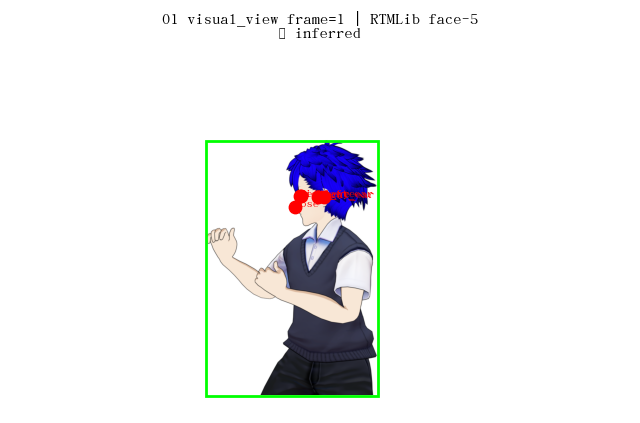

In [11]:
def preview_face5(view_name=None, frame_id=1):
    view_dir = VIEW_DIRS[0] if view_name is None else next(p for p in VIEW_DIRS if p.name == view_name)
    img, face5, skipped, reason = infer_face5_with_rtmlib(view_name=view_dir.name, frame_id=frame_id)
    bbox = load_bbox_for_frame(view_dir, frame_id)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    draw_bbox(plt.gca(), bbox, color='lime')
    if face5:
        xs = [v['x'] for v in face5.values()]
        ys = [v['y'] for v in face5.values()]
        plt.scatter(xs, ys, s=80, c='red', zorder=5)
        for name, p in face5.items():
            plt.text(p['x'], p['y'], name, fontsize=9, color='red')
    title = f'{view_dir.name} frame={frame_id} | RTMLib face-5'
    if skipped:
        title += f'\n⚠ 跳过补点（{reason}）'
    else:
        title += f'\n✓ {reason}'
    plt.title(title)
    plt.axis('off')
    plt.show()


preview_face5(frame_id=1)

## 标准格式预览（含 bbox + 可见性）

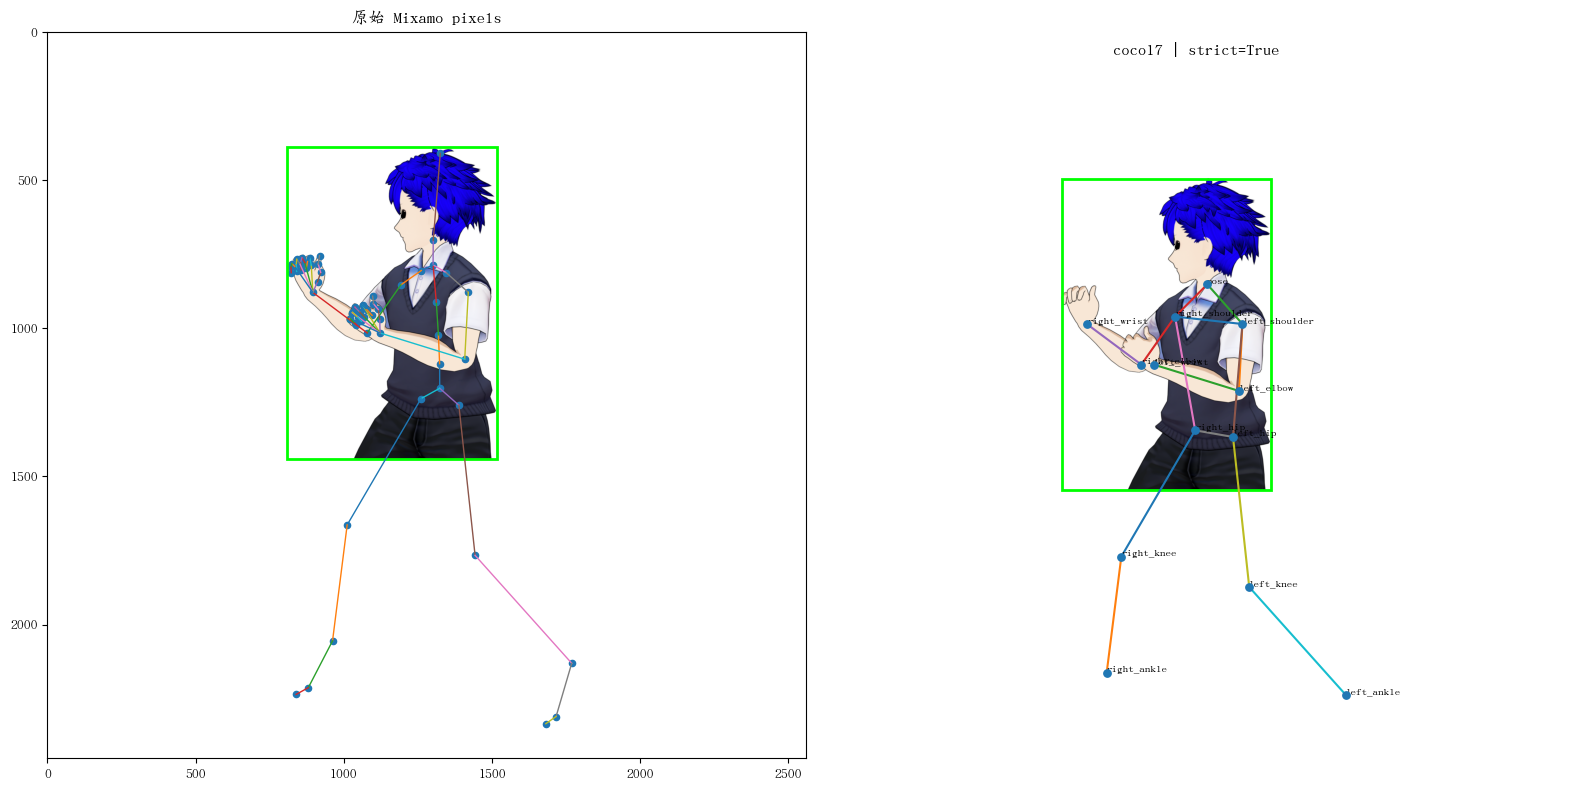

[coco17] 总点数=13, 可见(v=2)=9, 画面外(v=0)=4


In [12]:
def draw_standard_points(ax, points, image=None, title='', show_labels=True, edges=None,
                          bbox=None, only_visible=False):
    """
    only_visible=True 时只绘制 visibility==2 的点和边。
    """
    if image is not None:
        ax.imshow(image)
    if bbox is not None:
        draw_bbox(ax, bbox, color='lime', linewidth=2)

    visible_pts = {
        k: v for k, v in points.items()
        if not only_visible or v.get('visibility', 2) == 2
    }

    xs = [v['x'] for v in visible_pts.values()]
    ys = [v['y'] for v in visible_pts.values()]
    ax.scatter(xs, ys, s=28, zorder=5)

    if edges:
        for a, b in edges:
            if a in visible_pts and b in visible_pts:
                ax.plot(
                    [visible_pts[a]['x'], visible_pts[b]['x']],
                    [visible_pts[a]['y'], visible_pts[b]['y']],
                    linewidth=1.5
                )
    if show_labels:
        for name, p in visible_pts.items():
            ax.text(p['x'], p['y'], name, fontsize=8)
    ax.set_title(title)
    ax.axis('off')


def preview_standard_conversion(view_name=None, frame_id=1, standard='coco17',
                                  use_rtmlib_face=True, strict=True, show_labels=True):
    view_dir = VIEW_DIRS[0] if view_name is None else next(p for p in VIEW_DIRS if p.name == view_name)
    img  = read_image_rgb(frame_image_path(view_dir, frame_id))
    bbox = load_bbox_for_frame(view_dir, frame_id)
    mixamo_pixels = load_points_for_frame(view_dir, 'pixels', frame_id)

    face5 = {}
    skip_info = ''
    if use_rtmlib_face:
        try:
            _, face5, skipped, reason = infer_face5_with_rtmlib(
                view_name=view_dir.name, frame_id=frame_id, skip_if_face_outside=True)
            skip_info = f'（跳过: {reason}）' if skipped else f'（已补全: {reason}）'
        except Exception as e:
            skip_info = f'（RTMLib 失败: {e}）'

    std_points = convert_mixamo_to_standard(
        mixamo_pixels, standard=standard, extra_face_points=face5,
        strict=strict, img_shape=img.shape
    )
    edges = COCO17_EDGES if standard.lower() == 'coco17' else OPENPOSE18_EDGES

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    draw_points(axes[0], mixamo_pixels, '原始 Mixamo pixels', img, False, MIXAMO_EDGES, bbox=bbox)
    draw_standard_points(
        axes[1], std_points, img,
        title=f'{standard} | strict={strict} {skip_info}',
        show_labels=show_labels, edges=edges, bbox=bbox, only_visible=False
    )
    plt.tight_layout()
    plt.show()

    visible_cnt   = sum(1 for v in std_points.values() if v.get('visibility', 2) == 2)
    invisible_cnt = sum(1 for v in std_points.values() if v.get('visibility', 2) == 0)
    print(f'[{standard}] 总点数={len(std_points)}, 可见(v=2)={visible_cnt}, 画面外(v=0)={invisible_cnt}')


preview_standard_conversion(frame_id=1, standard='coco17', use_rtmlib_face=False, strict=True)

In [13]:
# 交互式：标准格式转换与预览

view_dropdown2   = widgets.Dropdown(options=[p.name for p in VIEW_DIRS], value=VIEW_DIRS[0].name, description='View')
frame_slider2    = widgets.IntSlider(value=1, min=1, max=72, step=1, description='Frame')
standard_drop    = widgets.Dropdown(options=['coco17', 'openpose18'], value='coco17', description='Standard')
rtmlib_check     = widgets.Checkbox(value=True, description='RTMLib补全面部5点')
strict_check     = widgets.Checkbox(value=True, description='strict')
labels_check2    = widgets.Checkbox(value=True, description='显示标签')

ui2 = widgets.VBox([
    widgets.HBox([view_dropdown2, frame_slider2]),
    widgets.HBox([standard_drop, rtmlib_check, strict_check, labels_check2]),
])
out2 = widgets.interactive_output(
    preview_standard_conversion,
    {'view_name': view_dropdown2, 'frame_id': frame_slider2, 'standard': standard_drop,
     'use_rtmlib_face': rtmlib_check, 'strict': strict_check, 'show_labels': labels_check2}
)
display(ui2, out2)

Output()

# 导出 COCO 标准 JSON（含 bbox + visibility）

In [14]:
def export_standard_json(view_name=None, frame_id=1, standard='coco17',
                          use_rtmlib_face=True, strict=True, save_path=None):
    """
    导出单帧标准格式 JSON。
    keypoints 格式兼容 COCO：
      每个关键点包含 {x, y, z, visibility}
      visibility: 0=画面外/不存在, 2=可见
    同时在 JSON 中记录 bbox: [x, y, w, h]
    """
    view_dir = VIEW_DIRS[0] if view_name is None else next(p for p in VIEW_DIRS if p.name == view_name)
    img  = read_image_rgb(frame_image_path(view_dir, frame_id))
    bbox = load_bbox_for_frame(view_dir, frame_id)
    mixamo_pixels = load_points_for_frame(view_dir, 'pixels', frame_id)

    face5, skip_reason = {}, 'not_used'
    if use_rtmlib_face:
        try:
            _, face5, skipped, skip_reason = infer_face5_with_rtmlib(
                view_name=view_dir.name, frame_id=frame_id, skip_if_face_outside=True)
        except Exception as e:
            skip_reason = f'error: {e}'

    std_points = convert_mixamo_to_standard(
        mixamo_pixels, standard=standard, extra_face_points=face5,
        strict=strict, img_shape=img.shape
    )

    # COCO 扁平化格式: [x1, y1, v1, x2, y2, v2, ...]
    order = COCO17_ORDER if standard.lower() == 'coco17' else OPENPOSE18_ORDER
    kps_flat = []
    for k in order:
        if k in std_points:
            p = std_points[k]
            kps_flat.extend([p['x'], p['y'], p.get('visibility', 2)])
        else:
            kps_flat.extend([0.0, 0.0, 0])   # 缺失点标记为画面外

    obj = {
        'view':       view_dir.name,
        'frame_id':   frame_id,
        'standard':   standard,
        'strict':     strict,
        'bbox':       bbox,                    # [x, y, w, h] COCO 格式
        'face5_info': skip_reason,
        'num_keypoints': sum(1 for v in std_points.values() if v.get('visibility', 2) > 0),
        'keypoints':  std_points,              # 结构化，方便人读
        'keypoints_flat': kps_flat,            # COCO 扁平格式
    }

    if save_path is None:
        save_path = ROOT / f'{view_prefix(view_dir)}_{frame_id:04d}_{standard}_strict{int(strict)}.json'
    save_path = Path(save_path)
    with open(save_path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    return obj


# 示例
result = export_standard_json(frame_id=1, standard='coco17', use_rtmlib_face=True, strict=True)
print('bbox:', result['bbox'])
print('num_keypoints:', result['num_keypoints'])
vis_summary = {k: v['visibility'] for k, v in result['keypoints'].items()}
print('visibility:', vis_summary)

bbox: [810, 389, 707, 1051]
num_keypoints: 13
visibility: {'nose': 2, 'left_eye': 2, 'right_eye': 2, 'left_ear': 2, 'right_ear': 2, 'left_shoulder': 2, 'right_shoulder': 2, 'left_elbow': 2, 'right_elbow': 2, 'left_wrist': 2, 'right_wrist': 2, 'left_hip': 2, 'right_hip': 2, 'left_knee': 0, 'right_knee': 0, 'left_ankle': 0, 'right_ankle': 0}


## 批量导出
遍历所有视角，导出全部帧（1~72）标准化关键点 JSON。

输出目录结构：
```
output_dir/
  ├── 01 visual_view/
  │   ├── frame_0001_coco17_strict1.json
  │   └── ...
  ├── 02 visual_view/
  └── ...
```

In [15]:
from tqdm.auto import tqdm

In [16]:
def batch_export_all_views_frames(standard='coco17', use_rtmlib_face=True,
                                   strict=True, output_dir=None):
    if output_dir is None:
        output_dir = ROOT / f'exported_{standard}_strict{int(strict)}'
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    print(f'任务开始: {len(VIEW_DIRS)} 视角 × 72 帧')
    print(f'standard={standard} | strict={strict} | RTMLib={use_rtmlib_face}')
    print(f'输出目录: {output_dir.resolve()}\n')

    stats = {'success': 0, 'failed': 0, 'face_skipped': 0}

    for view_dir in tqdm(VIEW_DIRS, desc='views'):
        view_out_dir = output_dir / view_dir.name
        view_out_dir.mkdir(exist_ok=True)

        for frame_id in tqdm(range(1, 73), desc=view_dir.name, leave=False):
            save_path = view_out_dir / f'frame_{frame_id:04d}_{standard}_strict{int(strict)}.json'
            try:
                result = export_standard_json(
                    view_name=view_dir.name, frame_id=frame_id,
                    standard=standard, use_rtmlib_face=use_rtmlib_face,
                    strict=strict, save_path=save_path
                )
                stats['success'] += 1
                if use_rtmlib_face and 'skipped' in str(result.get('face5_info', '')):
                    stats['face_skipped'] += 1
            except Exception as e:
                stats['failed'] += 1
                tqdm.write(f'[{view_dir.name} frame={frame_id}] 失败: {e}')

    print(f'\n完成. 成功={stats["success"]} | 失败={stats["failed"]} | 面部跳过={stats["face_skipped"]}')
    return output_dir, stats

In [17]:
output_dir, stats = batch_export_all_views_frames(
    standard='coco17',
    use_rtmlib_face=True,
    strict=True
)

任务开始: 5 视角 × 72 帧
standard=coco17 | strict=True | RTMLib=True
输出目录: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1



views:   0%|          | 0/5 [00:00<?, ?it/s]

01 visual_view:   0%|          | 0/72 [00:00<?, ?it/s]

02 visual_view:   0%|          | 0/72 [00:00<?, ?it/s]

03 visual_view:   0%|          | 0/72 [00:00<?, ?it/s]

04 visual_view:   0%|          | 0/72 [00:00<?, ?it/s]

05 visual_view:   0%|          | 0/72 [00:00<?, ?it/s]


完成. 成功=360 | 失败=0 | 面部跳过=0


# 成品 COCO-17 可视化预览

从已导出的 JSON 文件读回关键点，只显示 visibility=2（可见）的点和连线。

/tmp/ipykernel_17982/1502384851.py:80: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) AR PL UKai CN.
  plt.tight_layout()
/home/tvem/anaconda3/envs/anipose/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) AR PL UKai CN.
  fig.canvas.print_figure(bytes_io, **kw)


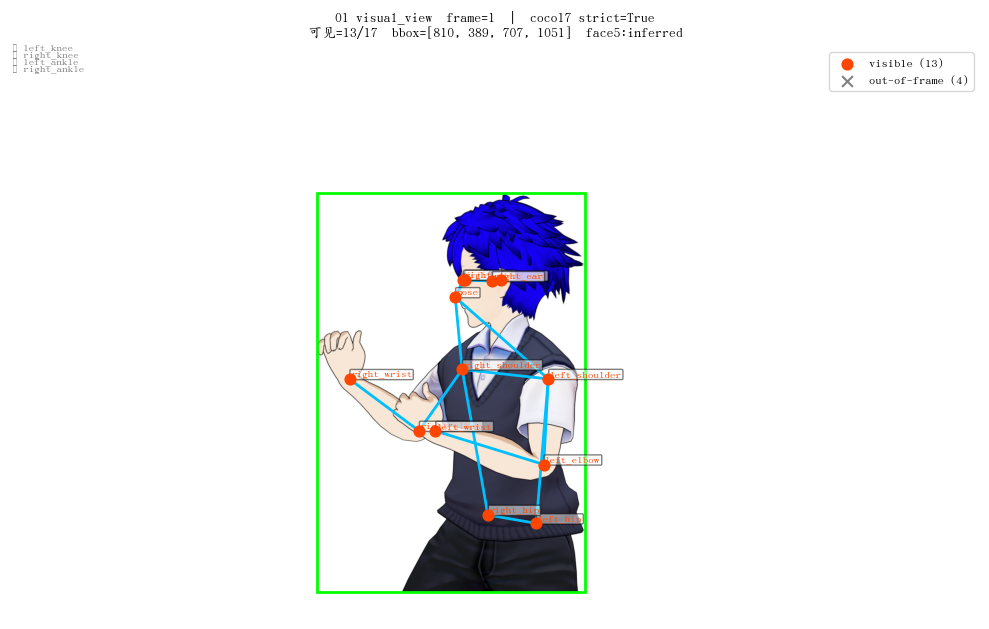

In [18]:
def load_exported_json(view_dir, frame_id, standard, strict, output_root=None):
    """
    读取已导出的标准 JSON 文件。
    """
    if output_root is None:
        output_root = ROOT / f'exported_{standard}_strict{int(strict)}'
    path = Path(output_root) / view_dir.name / f'frame_{frame_id:04d}_{standard}_strict{int(strict)}.json'
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def preview_coco17_result(view_name=None, frame_id=1, standard='coco17', strict=True,
                            show_labels=True, output_root=None):
    """
    可视化成品 COCO-17 关键点：
    - 绿色框: bbox
    - 彩色点+骨架: 仅 visibility=2（可见）的点
    - 灰色虚线: 画面外点位置标注（可选，用小叉标记）
    """
    view_dir = VIEW_DIRS[0] if view_name is None else next(p for p in VIEW_DIRS if p.name == view_name)
    img  = read_image_rgb(frame_image_path(view_dir, frame_id))
    h, w = img.shape[:2]

    data = load_exported_json(view_dir, frame_id, standard, strict, output_root)
    if data is None:
        print(f'找不到导出文件，请先运行 batch_export_all_views_frames()')
        return

    bbox = data.get('bbox') or load_bbox_for_frame(view_dir, frame_id)
    # bbox = data.get('bbox')
    kps  = data.get('keypoints', {})
    edges = COCO17_EDGES if standard == 'coco17' else OPENPOSE18_EDGES

    visible_pts   = {k: v for k, v in kps.items() if v.get('visibility', 2) == 2}
    invisible_pts = {k: v for k, v in kps.items() if v.get('visibility', 2) == 0}

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img)

    # bbox
    draw_bbox(ax, bbox, color='lime', linewidth=2)

    # 骨架连线（只连可见点）
    for a, b in edges:
        if a in visible_pts and b in visible_pts:
            ax.plot(
                [visible_pts[a]['x'], visible_pts[b]['x']],
                [visible_pts[a]['y'], visible_pts[b]['y']],
                color='deepskyblue', linewidth=2, zorder=3
            )

    # 可见关键点
    if visible_pts:
        xs = [v['x'] for v in visible_pts.values()]
        ys = [v['y'] for v in visible_pts.values()]
        ax.scatter(xs, ys, s=60, c='orangered', zorder=5, label=f'visible ({len(visible_pts)})')
        if show_labels:
            for name, p in visible_pts.items():
                ax.text(p['x']+4, p['y']-4, name, fontsize=8, color='orangered',
                        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5))

    # 画面外点：用小叉标注在图像边缘外提示
    if invisible_pts:
        ax.scatter([], [], s=60, c='gray', marker='x', label=f'out-of-frame ({len(invisible_pts)})')
        if show_labels:
            for name in invisible_pts:
                ax.text(5, 15 + list(invisible_pts.keys()).index(name) * 18,
                        f'✗ {name}', fontsize=8, color='gray', transform=ax.transData)

    face5_info = data.get('face5_info', '')
    ax.set_title(
        f'{view_dir.name}  frame={frame_id}  |  {standard} strict={strict}\n'
        f'可见={len(visible_pts)}/{len(kps)}  bbox={bbox}  face5:{face5_info}',
        fontsize=10
    )
    ax.legend(loc='upper right', fontsize=9)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# 快速预览
preview_coco17_result(frame_id=1, standard='coco17', strict=True, show_labels=True)

In [ ]:
# 交互式成品 COCO-17 可视化

_std_choices = ['coco17', 'openpose18']

v3_view   = widgets.Dropdown(options=[p.name for p in VIEW_DIRS], value=VIEW_DIRS[0].name, description='View')
v3_frame  = widgets.IntSlider(value=1, min=1, max=72, step=1, description='Frame')
v3_std    = widgets.Dropdown(options=_std_choices, value='coco17', description='Standard')
v3_strict = widgets.Checkbox(value=True, description='strict')
v3_labels = widgets.Checkbox(value=True, description='显示标签')

ui3 = widgets.VBox([
    widgets.HBox([v3_view, v3_frame]),
    widgets.HBox([v3_std, v3_strict, v3_labels]),
])
out3 = widgets.interactive_output(
    preview_coco17_result,
    {
        'view_name':   v3_view,
        'frame_id':    v3_frame,
        'standard':    v3_std,
        'strict':      v3_strict,
        'show_labels': v3_labels,
    }
)

display(ui3, out3)

Output()

In [20]:
# 诊断：打印 Bounding_Box.json 的前10个 key
sample_view = VIEW_DIRS[0]
bbox_data = load_json(bbox_path(sample_view))
print('bbox keys 示例:', list(bbox_data.keys())[:10])
print('frame=1 尝试匹配结果:', load_bbox_for_frame(sample_view, 10))

bbox keys 示例: ['0001_1', '0002_1', '0003_1', '0004_1', '0005_1', '0006_1', '0007_1', '0008_1', '0009_1', '0010_1']
frame=1 尝试匹配结果: [909, 121, 612, 1319]


In [23]:
# ============================================================
# 可视化验证单元格
# 功能：从生成的 COCO JSON 中随机抽样，
#       在渲染图上叠加 bbox + 可见关键点 + 骨架连线
# ============================================================

import json
import random
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import ipywidgets as widgets
from IPython.display import display

# ── 参数（与上方配置单元格保持一致）────────────────────────────
ROOT_DIR       = Path('./68 model').resolve()   # 数据根目录
TRAIN_JSON     = './anime_coco_train.json'
VAL_JSON       = './anime_coco_val.json'

COCO17_ORDER = [
    'nose',
    'left_eye', 'right_eye',
    'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder',
    'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist',
    'left_hip', 'right_hip',
    'left_knee', 'right_knee',
    'left_ankle', 'right_ankle',
]

# COCO-17 骨架边（1-indexed → 转为 0-indexed）
COCO17_EDGES_0IDX = [
    (15, 13), (13, 11), (16, 14), (14, 12), (11, 12),
    (5, 11),  (6, 12),  (5, 6),   (5, 7),   (6, 8),
    (7, 9),   (8, 10),  (1, 2),   (0, 1),   (0, 2),
    (1, 3),   (2, 4),   (3, 5),   (4, 6),
]

# 左侧关节（蓝色）/ 右侧关节（红色）/ 中轴（绿色）
LEFT_IDX  = {1, 3, 5, 7, 9, 11, 13, 15}   # left_eye/ear/shoulder/elbow/wrist/hip/knee/ankle
RIGHT_IDX = {2, 4, 6, 8, 10, 12, 14, 16}
KP_COLORS = []
for i in range(17):
    if i in LEFT_IDX:
        KP_COLORS.append('dodgerblue')
    elif i in RIGHT_IDX:
        KP_COLORS.append('tomato')
    else:
        KP_COLORS.append('gold')   # nose


def _edge_color(i, j):
    """根据边两端关节决定连线颜色。"""
    if i in LEFT_IDX and j in LEFT_IDX:
        return 'dodgerblue'
    if i in RIGHT_IDX and j in RIGHT_IDX:
        return 'tomato'
    return 'limegreen'


# ── 加载 COCO JSON ──────────────────────────────────────────
def load_coco(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        return json.load(f)

print('加载训练/验证集 JSON...')
train_coco = load_coco(TRAIN_JSON)
val_coco   = load_coco(VAL_JSON)

# 建立 image_id -> annotation 的索引
def build_index(coco_data):
    img_map  = {img['id']: img  for img in coco_data['images']}
    ann_map  = {ann['image_id']: ann for ann in coco_data['annotations']}
    img_ids  = list(img_map.keys())
    return img_map, ann_map, img_ids

train_img_map, train_ann_map, train_ids = build_index(train_coco)
val_img_map,   val_ann_map,   val_ids   = build_index(val_coco)

print(f'训练集: {len(train_ids)} 张 | 验证集: {len(val_ids)} 张')


# ── 可视化核心函数 ───────────────────────────────────────────
def visualize_sample(img_id, img_map, ann_map, split_name, show_labels=True):
    img_info = img_map[img_id]
    ann      = ann_map.get(img_id)
    if ann is None:
        print(f'image_id={img_id} 没有标注')
        return

    # 读图
    img_path = os.path.join(str(ROOT_DIR), img_info['file_name'])
    try:
        img = np.array(Image.open(img_path).convert('RGB'))
    except Exception as e:
        print(f'图像读取失败: {img_path}\n{e}')
        return

    bbox     = ann['bbox']            # [x, y, w, h]
    kps_flat = ann['keypoints']       # [x0,y0,v0, x1,y1,v1, ...]
    num_kpts = ann['num_keypoints']

    kps = np.array(kps_flat, dtype=float).reshape(-1, 3)  # (17, 3)

    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    ax.imshow(img)

    # ── BBox ─────────────────────────────────────────────────
    rect = mpatches.Rectangle(
        (bbox[0], bbox[1]), bbox[2], bbox[3],
        linewidth=2, edgecolor='lime', facecolor='none', label='bbox'
    )
    ax.add_patch(rect)

    # ── 骨架连线（只连两端都可见的点）───────────────────────
    for i, j in COCO17_EDGES_0IDX:
        if kps[i, 2] == 2 and kps[j, 2] == 2:
            ax.plot(
                [kps[i, 0], kps[j, 0]],
                [kps[i, 1], kps[j, 1]],
                color=_edge_color(i, j),
                linewidth=2, alpha=0.85, zorder=3
            )

    # ── 关键点 ───────────────────────────────────────────────
    for idx, (x, y, v) in enumerate(kps):
        if v == 2:
            ax.scatter(x, y, s=55, color=KP_COLORS[idx], zorder=5,
                       edgecolors='white', linewidths=0.6)
            if show_labels:
                ax.text(x + 4, y - 5, COCO17_ORDER[idx],
                        fontsize=7.5, color='white',
                        bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.45))
        elif v == 0:
            # 画面外点：用半透明叉标记（可选，注释掉则不显示）
            ax.scatter(x if x != 0 else -999, y if y != 0 else -999,
                       s=30, color='gray', marker='x', alpha=0.4, zorder=2)

    # 图例
    legend_elements = [
        mpatches.Patch(facecolor='dodgerblue', label='左侧关节'),
        mpatches.Patch(facecolor='tomato',     label='右侧关节'),
        mpatches.Patch(facecolor='gold',       label='鼻子'),
        mpatches.Patch(facecolor='none', edgecolor='lime', linewidth=2, label='bbox'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8, framealpha=0.7)

    ax.set_title(
        f'[{split_name}] id={img_id}  file={os.path.basename(img_info["file_name"])}\n'
        f'可见关键点={num_kpts}/17  bbox=[{bbox[0]:.0f},{bbox[1]:.0f},{bbox[2]:.0f},{bbox[3]:.0f}]',
        fontsize=10
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# ── 交互式控件 ───────────────────────────────────────────────
split_drop  = widgets.Dropdown(options=['train', 'val'], value='train', description='Split')
idx_slider  = widgets.IntSlider(value=0, min=0, max=len(train_ids)-1, step=1, description='Index')
label_check = widgets.Checkbox(value=True, description='显示标签')
random_btn  = widgets.Button(description='随机跳转', button_style='info', icon='random')

def update_max(*args):
    ids = train_ids if split_drop.value == 'train' else val_ids
    idx_slider.max = len(ids) - 1
    idx_slider.value = min(idx_slider.value, idx_slider.max)

split_drop.observe(update_max, names='value')

def on_random(_):
    ids = train_ids if split_drop.value == 'train' else val_ids
    idx_slider.value = random.randint(0, len(ids) - 1)

random_btn.on_click(on_random)

def show(split, index, show_labels):
    if split == 'train':
        img_id = train_ids[index]
        visualize_sample(img_id, train_img_map, train_ann_map, 'train', show_labels)
    else:
        img_id = val_ids[index]
        visualize_sample(img_id, val_img_map, val_ann_map, 'val', show_labels)

ui  = widgets.VBox([
    widgets.HBox([split_drop, idx_slider, label_check, random_btn])
])
out = widgets.interactive_output(show, {
    'split':       split_drop,
    'index':       idx_slider,
    'show_labels': label_check,
})
display(ui, out)

加载训练/验证集 JSON...
训练集: 306 张 | 验证集: 54 张


Output()